## Import libraries

In [6]:
import os
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## Set seed

In [13]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Set paths and parameters

In [14]:
TRAIN_DIR = "./train"
VAL_DIR = "./val"
TEST_DIR = "./test"

IMAGE_HEIGHT = 155
IMAGE_WIDTH = 220
BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3

## Define the preprocessing

In [15]:
class InvertTransform:
    def __call__(self, img):
        return ImageOps.invert(img)

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    InvertTransform(),
    transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    InvertTransform(),
    transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

## Loading the datasets

In [16]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_test_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("First 10 class names:", class_names[:10])

Number of classes: 160
Train images: 2560
Validation images: 480
Test images: 800
First 10 class names: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']


## Visualize some preprocessed images

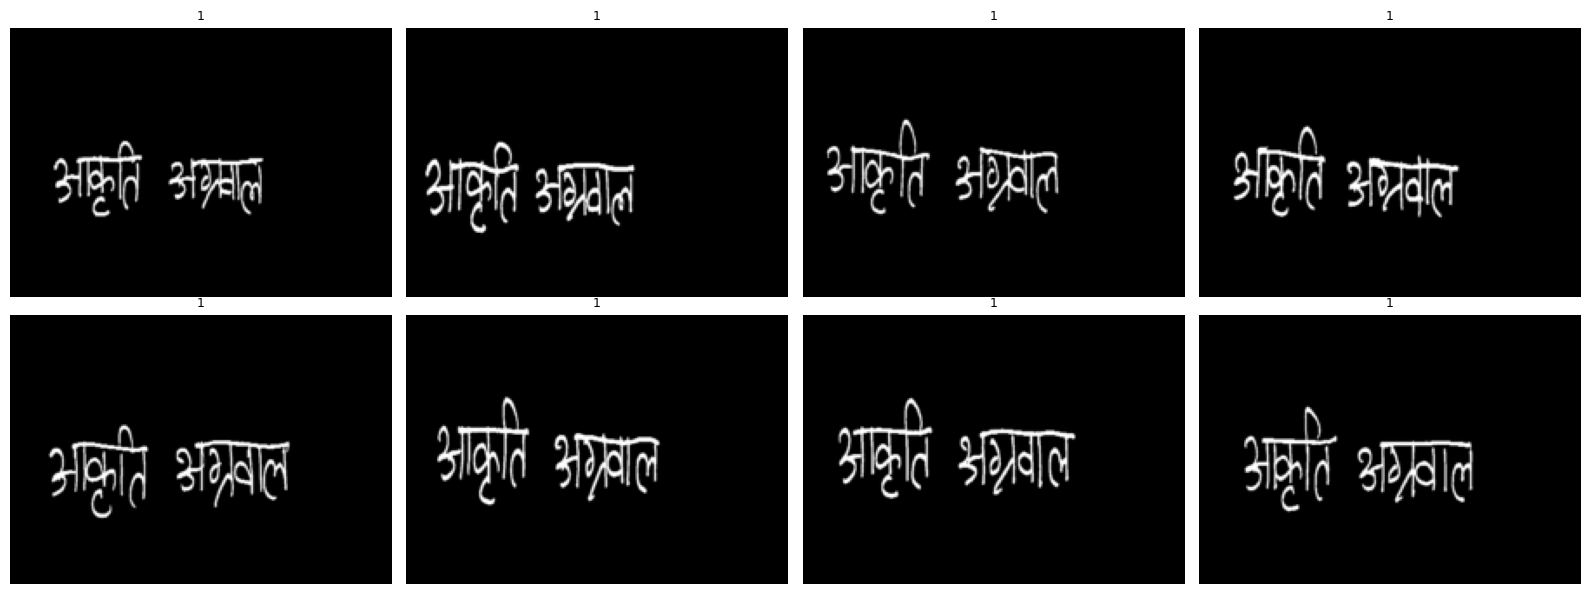

In [17]:
def show_batch(dataset, class_names, num_images=8):
    plt.figure(figsize=(16, 6))
    for i in range(num_images):
        img, label = dataset[i]
        img = img.squeeze().numpy()

        plt.subplot(2, 4, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(class_names[label], fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, class_names, num_images=8)

## Define the CNN model

In [18]:
class SignatureCNN(nn.Module):
    def __init__(self, num_classes):
        super(SignatureCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 9 * 13, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SignatureCNN(num_classes).to(device)
print(model)

SignatureCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=29952, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=160, bias=True)
 

## Loss and optimizer

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training and evaluation functions

In [20]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, all_labels, all_preds

## Training the model

In [21]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 50)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

elapsed = time.time() - start_time
print(f"Training finished in {elapsed / 60:.2f} minutes")
print(f"Best validation accuracy: {best_val_acc:.4f}")

Epoch 1/15
Train Loss: 5.0809 | Train Acc: 0.0051
Val   Loss: 5.0755 | Val   Acc: 0.0063
--------------------------------------------------
Epoch 2/15
Train Loss: 5.0764 | Train Acc: 0.0059
Val   Loss: 5.0755 | Val   Acc: 0.0063
--------------------------------------------------
Epoch 3/15
Train Loss: 5.0765 | Train Acc: 0.0031
Val   Loss: 5.0755 | Val   Acc: 0.0063
--------------------------------------------------
Epoch 4/15
Train Loss: 5.0764 | Train Acc: 0.0055
Val   Loss: 5.0754 | Val   Acc: 0.0063
--------------------------------------------------
Epoch 5/15
Train Loss: 5.0764 | Train Acc: 0.0031
Val   Loss: 5.0754 | Val   Acc: 0.0063
--------------------------------------------------
Epoch 6/15
Train Loss: 5.0764 | Train Acc: 0.0023
Val   Loss: 5.0754 | Val   Acc: 0.0063
--------------------------------------------------
Epoch 7/15
Train Loss: 5.0764 | Train Acc: 0.0023
Val   Loss: 5.0754 | Val   Acc: 0.0063
--------------------------------------------------
Epoch 8/15
Train Los

## Loading best model and evaluate on test set

In [22]:
model.load_state_dict(best_model_wts)

test_loss, test_acc, test_labels, test_preds = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 5.0755
Test Accuracy: 0.0063


## Plot training and validation loss

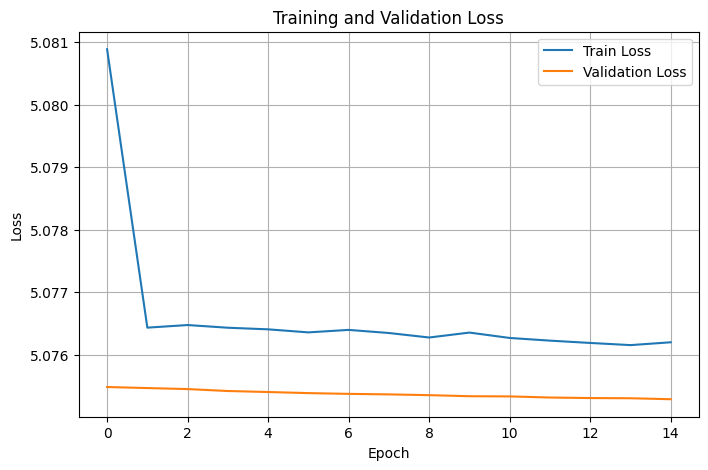

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## Plot training and validation accuracy

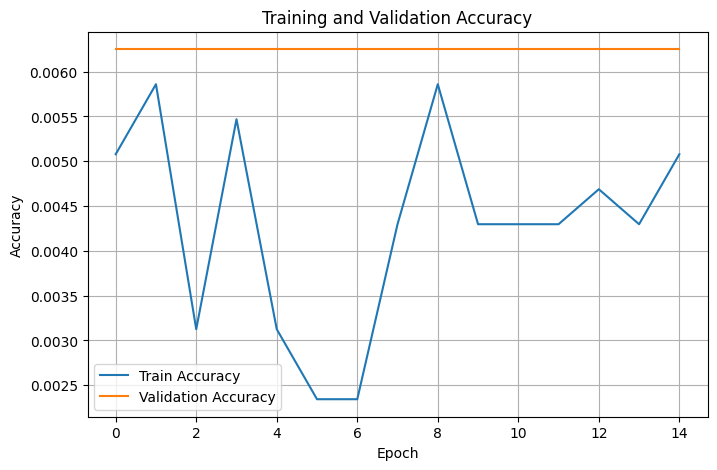

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## test predictions

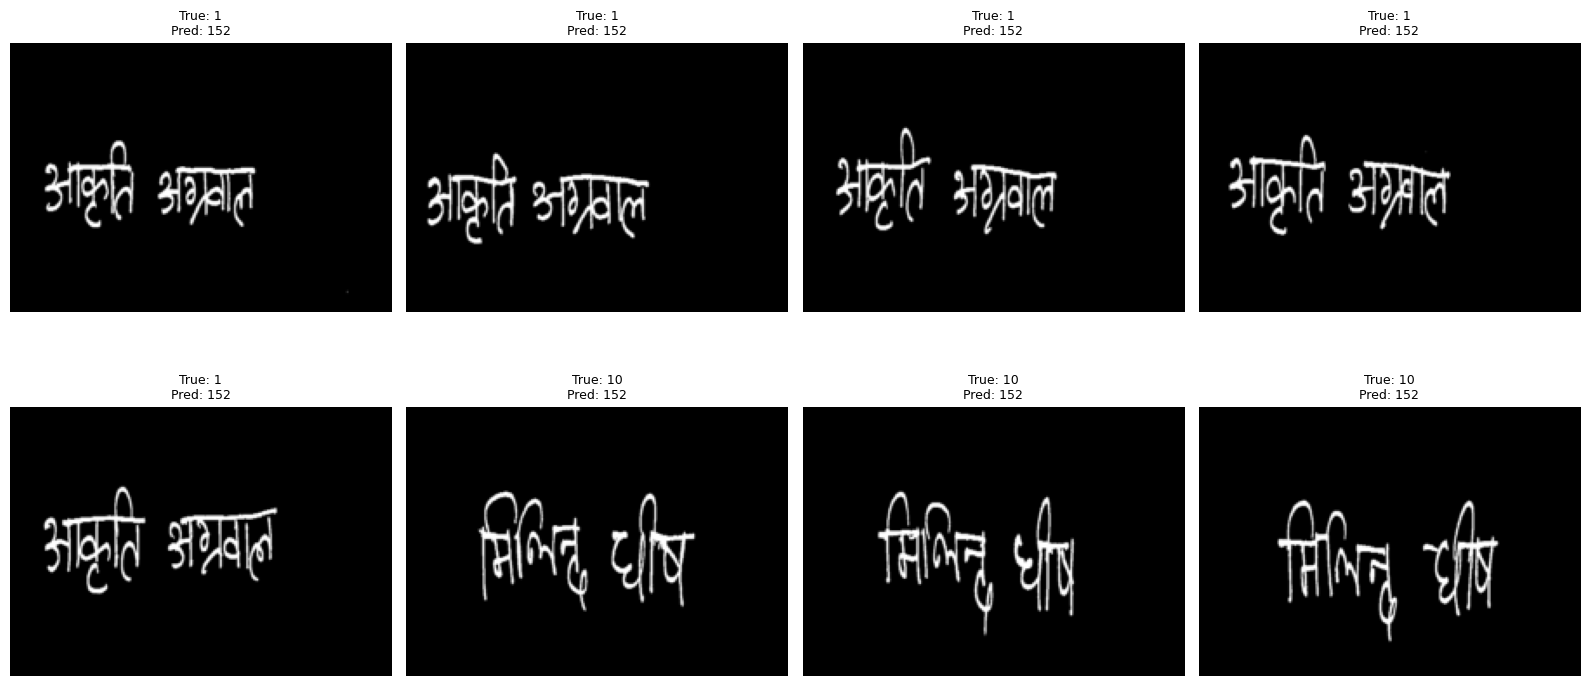

In [25]:
def denormalize(img_tensor):
    return img_tensor * 0.5 + 0.5

images, labels = next(iter(test_loader))
images_device = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images_device)
    preds = torch.argmax(outputs, dim=1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(16, 8))
for i in range(min(8, len(images))):
    img = denormalize(images[i]).squeeze().numpy()
    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Summary

In [27]:
print("========== SUMMARY ==========")
print(f"Number of classes      : {num_classes}")
print(f"Training samples       : {len(train_dataset)}")
print(f"Validation samples     : {len(val_dataset)}")
print(f"Test samples           : {len(test_dataset)}")
print(f"Best validation acc    : {best_val_acc:.4f}")
print(f"Final test accuracy    : {test_acc:.4f}")
print(f"Final test loss        : {test_loss:.4f}")
print("=============================================")

========== SUMMARY ==========
Number of classes      : 160
Training samples       : 2560
Validation samples     : 480
Test samples           : 800
Best validation acc    : 0.0063
Final test accuracy    : 0.0063
Final test loss        : 5.0755
